In [1]:
import sys
sys.path.append('../../../../')

In [2]:
from examples.batch_elution.process import process

In [3]:
from CADETProcess.simulator import Cadet
process_simulator = Cadet()
simulation_results = process_simulator.simulate(process)

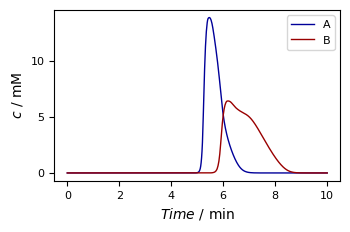

In [4]:
_ = simulation_results.solution.outlet.outlet.plot()

In [5]:
from CADETProcess.fractionation import Fractionator
fractionator = Fractionator(
    simulation_results.chromatograms,
    simulation_results.process.process_meta,
)

[INFO 08-12 16:24:11] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.52


In [6]:
fractionator.add_fractionation_event('start_A', 'A', 5*60, 'outlet')
fractionator.add_fractionation_event('end_A', -1, 5.75*60)
fractionator.add_fractionation_event('start_B', 'B', 6.5*60)
fractionator.add_fractionation_event('end_B', -1, 9*60)

In [7]:
print(fractionator.performance)

Performance(mass=array([0.00039127, 0.00038088]), concentration=array([8.69481923, 2.5392047 ]), purity=array([0.99721982, 0.97224997]), recovery=array([0.65211144, 0.63480118]), productivity=array([0.00800824, 0.00779566]), eluent_consumption=array([0.72456827, 0.70533464]) mass_balance_difference=array([-1.66089849e-10,  1.07870550e-10]))


In [8]:
_ = fractionator.plot_fraction_signal()

In [9]:
from CADETProcess.fractionation import FractionationOptimizer
fractionation_optimizer = FractionationOptimizer()

In [10]:
fractionator = fractionation_optimizer.optimize_fractionation(simulation_results, purity_required=[0.95, 0])

In [11]:
print(fractionator.performance)

Performance(mass=array([0.00050151, 0.        ]), concentration=array([5.85281605, 0.        ]), purity=array([0.94708247, 0.        ]), recovery=array([0.83584726, 0.        ]), productivity=array([0.0102646, 0.       ]), eluent_consumption=array([0.92871917, 0.        ]) mass_balance_difference=array([-1.62758040e-10,  8.93819462e-11]))


In [12]:
_ = fractionator.plot_fraction_signal()

In [13]:
fractionator = fractionation_optimizer.optimize_fractionation(simulation_results, purity_required=[0, 0.95])

print(fractionator.performance)
_ = fractionator.plot_fraction_signal()

Performance(mass=array([0.        , 0.00044048]), concentration=array([0.        , 2.16285464]), purity=array([0.        , 0.94573043]), recovery=array([0.        , 0.73413667]), productivity=array([0.        , 0.00901555]), eluent_consumption=array([0.        , 0.81570741]) mass_balance_difference=array([-3.06442352e-10,  1.14738028e-10]))


In [14]:
fractionator = fractionation_optimizer.optimize_fractionation(simulation_results, purity_required=[0.8, 0.8])

print(fractionator.performance)
_ = fractionator.plot_fraction_signal()

Performance(mass=array([0.00051319, 0.00056069]), concentration=array([6.04123446, 2.48631275]), purity=array([0.9288585 , 0.86593798]), recovery=array([0.85532456, 0.93449067]), productivity=array([0.01050379, 0.01147599]), eluent_consumption=array([0.95036062, 1.03832296]) mass_balance_difference=array([-1.75196402e-10,  1.10775117e-10]))


In [15]:
from CADETProcess.performance import RankedPerformance
ranking = [1, 1]
def alternative_objective(performance):
	performance = RankedPerformance(performance, ranking)
	return performance.mass * performance.concentration

fractionator = fractionation_optimizer.optimize_fractionation(
	simulation_results, purity_required=[0.95, 0.95],
	obj_fun=alternative_objective,
    n_objectives=1,
    minimize=False,
)

print(fractionator.performance)
_ = fractionator.plot_fraction_signal()

Performance(mass=array([0.00046172, 0.00041165]), concentration=array([11.39015705,  4.00882218]), purity=array([0.96717297, 0.94972338]), recovery=array([0.76953533, 0.68607612]), productivity=array([0.00945026, 0.00842534]), eluent_consumption=array([0.85503926, 0.7623068 ]) mass_balance_difference=array([-2.50588673e-10,  1.07778438e-10]))


In [16]:
from examples.load_wash_elute.lwe_flow_rate import process

from CADETProcess.simulator import Cadet
process_simulator = Cadet()
simulation_results = process_simulator.simulate(process)

In [17]:
fractionator = fractionation_optimizer.optimize_fractionation(
    simulation_results,
    components=['A', 'B', 'C'],
    purity_required=[0.95, 0.95, 0.95]
)
print(fractionator.performance)
_ = fractionator.plot_fraction_signal()

Performance(mass=array([6.32249314e-07, 3.07205035e-07, 5.09536350e-07]), concentration=array([0.0123222 , 0.04193683, 0.013091  ]), purity=array([0.95146241, 0.94964323, 0.95062827]), recovery=array([0.94595162, 0.45963055, 0.76235233]), productivity=array([0.00045635, 0.00022174, 0.00036778]), eluent_consumption=array([0.00475353, 0.0023097 , 0.00383092]) mass_balance_difference=array([2.09449440e-13, 9.58813983e-14, 3.26463333e-16]))
